In [1]:
#Fundatec / Procomer
#Programa técnico en aseguramiento de la calidad



##Descriptive statistical analysis of random data
###Frank Berrocal  


##Mayo 2026

In [2]:
#import sys
#!{sys.executable} -m pip install polars
%pip install xgboost




Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import numpy as np
import polars as pl
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer



# Orthogonal Feature Scaling

# Working with the complete dataset
df_financial_nD = pl.read_csv("Synthetic_Financial_datasets_log.csv")


In [4]:
# 1. Initialize the Lazy Engine
optimized_request = (
    df_financial_nD.lazy()

    # 1. Extraction Dimensionnelle
    .select(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud'])

    # 2. Réétiquetage Métadonnées (Zéro duplication mémoire)
    .rename({
        'amount': 'Amount',
        'oldbalanceOrg': 'Old_Balance',
        'newbalanceOrig': 'New_Balance',
        'isFraud': 'Fraud_Potential'
    })
)

# 2. Execution Trigger
# The machine's query optimizer evaluates the entire plan, drops unnecessary data
# before it ever reaches RAM, and executes the math via multi-threading.
complete_vector = optimized_request.collect()

In [5]:
complete_vector.describe()

statistic,Amount,Old_Balance,New_Balance,Fraud_Potential
str,f64,f64,f64,f64
"""count""",9.99999e5,9.99999e5,9.99999e5,9.99999e5
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",160250.057147,877670.637884,898346.884243,0.000535
"""std""",259258.54236,2.9824e6,3.0193e6,0.023124
"""min""",0.1,0.0,0.0,0.0
"""25%""",12759.94,0.0,0.0,0.0
"""50%""",79537.26,15957.0,0.0,0.0
"""75%""",216606.82,139751.93,179790.75,0.0
"""max""",1e7,3.8939e7,3.8946e7,1.0


In [6]:
# Robust Scaling Multidimensional

# np.nanmedian(..., axis=0), np.nanpercentile(..., axis=0),
# and numpy broadcasting require a numpy array, not a Polars DataFrame.


## Descriptive measurements

# count valid elements


def nan_element_count(n_array):
    return np.sum(np.isnan(n_array))  # count of NaN, not valid

# calculate mode


def mode_calculation(n_array):
    mode_result = stats.mode(n_array, keepdims=False)
    le_mode = mode_result.mode
    frequence_du_mode = mode_result.count
    return le_mode, frequence_du_mode
    
## Variability measurements

# coefficient of variation



def coefficient_variation(n_array):
    cv = 0
    cv = ((np.std(n_array)/np.mean(n_array))*100)
    return cv

# percentiles


def percentileCalculation(n_array):
    quantile25, quantile50, quantile75 = np.percentile(
        n_array, [25, 50, 75])
    return quantile25, quantile50, quantile75


## Geometry measurements

# 1. Quantify Asymmetry
# bias=False applies the sample correction factor (Bessel's correction logic) for finite N
# nan_policy='omit' ensures the C-loop does not crash if corrupted memory (NaN) is encountered
def skewness_calculation(n_array):
    asymmetry_factor = skew(n_array,
                            bias=False, nan_policy='omit')
    return asymmetry_factor


# 2. Quantify Tail Weight / Outlier Propensity
# fisher=True sets the Normal baseline to 0.0


def kurtosis_calculation(n_array):
    tail_extremity = kurtosis(n_array,
                              fisher=True, bias=False, nan_policy='omit')
    return tail_extremity


# 3.  Fisher's Coefficient
def fisher_calculation(n_array):
    mean = np.mean(n_array, axis=0)
    std  = np.std(n_array, axis=0)
    return np.mean((n_array - mean) ** 3, axis=0) / std ** 3

# 4.  Pearson's Coefficient


def pearson_calculation(n_array):
    return 3 * (np.mean(n_array, axis=0) - np.median(n_array, axis=0)) / np.std(n_array, axis=0)



# Data model transformation


def logarithmic_transformation_algorithm(n_array):
    # use log1p to avoid logarithmic explosion when log(0)
    # forced used in finances since you can have 0 values.
    vector_log = np.log1p(n_array)
    return vector_log

# Data model compression


def tensor_X_conversion(n_array):
    tensor_X = (
        n_array
        .select(['Amount', 'Old_Balance', 'New_Balance'])
        .cast(pl.Float64)
        .to_numpy()
    )
    return tensor_X


def tensor_Y_conversion(n_array):
    tensor_X = (
        n_array
        .get_column('Fraud_Potential')
        .cast(pl.Int8)
        .to_numpy()
    )
    return tensor_X


# data types conversion
x_features = tensor_X_conversion(complete_vector)
y_target = tensor_Y_conversion(complete_vector)


def robust_scaling_multiDim_algorithm(features):  # no global leak
    medians = np.nanmedian(features, axis=0)
    percentiles = np.nanpercentile(features, [25, 75], axis=0)
    iqrs = percentiles[1] - percentiles[0]
    iqrs = percentiles[1] - percentiles[0]
    iqrs = np.where(iqrs == 0, 1e-9, iqrs)
    return (features - medians) / iqrs

    

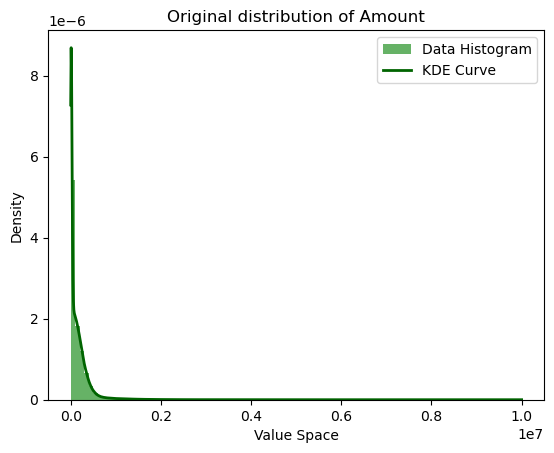

In [7]:
# 1. Generate the normalized histogram canvas for the non- transformed, non-compressed dataset
# Note: density=True is mandatory for the curve's area to align with the bars
data_slice = x_features[:, 0]
plt.hist(data_slice, bins=100, density=True, alpha=0.6, color='g', label='Data Histogram')

# 2. Compute the non-parametric density estimation
kde = gaussian_kde(data_slice)

# 3. Create a continuous, linearly spaced axis line across the data range
x_axis = np.linspace(data_slice.min(), data_slice.max(), 1000)

# 4. Project the curve over the histogram
plt.plot(x_axis, kde(x_axis), color='darkgreen', linewidth=2, label='KDE Curve')

plt.title('Original distribution of Amount')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

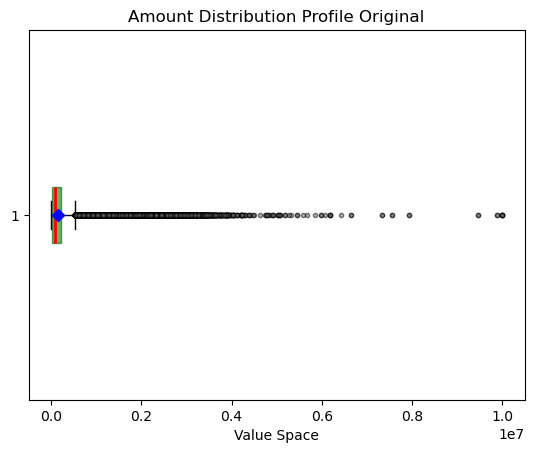

In [8]:
plt.boxplot(data_slice, 
            vert=False, 
            patch_artist=True,
            showmeans=True,  # <-- CRITICAL TRIGGER REQUIRED FOR meanprops
            boxprops=dict(facecolor='g', color='darkgreen', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='blue', markerfacecolor='blue', markersize=6),
            flierprops=dict(marker='o', markerfacecolor='dimgray', markersize=3, alpha=0.5))

plt.title('Amount Distribution Profile Original')
plt.xlabel('Value Space')
plt.show()

In [9]:
# Measures of variablity
print(f"\n\nMeasures of variability\n")
print(f"Range: {np.ptp(x_features, axis = 0)}")  # difference is too low
print(f"Variance: {np.var(x_features, axis = 0)}")
# same number, no NaN values found
print(f"NaN Variance: {np.nanvar(x_features, axis = 0)}")
print(f"Standard Deviation: {np.std(x_features, axis = 0)}")
print(f"Coefficient Variation: {coefficient_variation(x_features)}%")
# same number, no NaN values found
print(f"NaN STD: {np.nanstd(x_features, axis = 0)}")

print(f"\n\nMeasures of geometry\n")
print(f"Fisher's Coefficient: {fisher_calculation(x_features)}")
print(f"Pearson's Coefficient: {pearson_calculation(x_features)}")
print(f"Skewness: {skewness_calculation(x_features)}")
print(f"Kurtosis: {kurtosis_calculation(x_features)}")




Measures of variability

Range: [ 9999999.9  38939424.03 38946233.02]
Variance: [6.72149246e+10 8.89482609e+12 9.11632897e+12]
NaN Variance: [6.72149246e+10 8.89482609e+12 9.11632897e+12]
Standard Deviation: [ 259258.4127307  2982419.50248704 3019325.91340732]
Coefficient Variation: 384.0410274950471%
NaN STD: [ 259258.4127307  2982419.50248704 3019325.91340732]


Measures of geometry

Fisher's Coefficient: [5.43145082 5.11441153 5.04927733]
Pearson's Coefficient: [0.93396542 0.86679319 0.8925968 ]
Skewness: [5.43145896 5.1144192  5.0492849 ]
Kurtosis: [62.91435029 30.69148876 29.94303087]


In [10]:
# Data Model Transformation
## Logarithmic Transformation

complete_vector_log = logarithmic_transformation_algorithm(x_features)

print(f"\n\nMeasures of geometry\n")
print(f"Fisher's Coefficient: {fisher_calculation(complete_vector_log)}")
print(f"Pearson's Coefficient: {pearson_calculation(complete_vector_log)}")
print(f"Skewness: {skewness_calculation(complete_vector_log)}")
print(f"Kurtosis: {kurtosis_calculation(complete_vector_log)}")



Measures of geometry

Fisher's Coefficient: [-0.61192382 -0.28228665  0.38994616]
Pearson's Coefficient: [-0.72846413 -1.12638942  2.60117683]
Skewness: [-0.61192474 -0.28228707  0.38994675]
Kurtosis: [ 0.02737936 -1.43250915 -1.65370443]


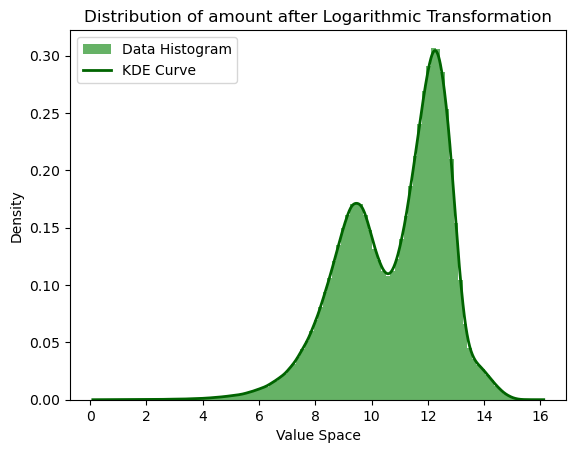

In [11]:
# 1. Generate the normalized histogram canvas for the transformed dataset
# Note: density=True is mandatory for the curve's area to align with the bars
data_slice = complete_vector_log[:, 0]
plt.hist(data_slice, bins=100, density=True, alpha=0.6, color='g', label='Data Histogram')

# 2. Compute the non-parametric density estimation
kde = gaussian_kde(data_slice)

# 3. Create a continuous, linearly spaced axis line across the data range
x_axis = np.linspace(data_slice.min(), data_slice.max(), 1000)

# 4. Project the curve over the histogram
plt.plot(x_axis, kde(x_axis), color='darkgreen', linewidth=2, label='KDE Curve')

plt.title('Distribution of amount after Logarithmic Transformation')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

In [12]:
# Robust Scaling Multidimensional
print(f"\n\nData Model Compression\n")
print(f"Robust Scaling\n")

complete_vector_compressed = robust_scaling_multiDim_algorithm(complete_vector_log)

print(f"Measures of variability\n")
print(f"Range: {np.ptp(complete_vector_compressed, axis=0)}")       # ← was complete_vector_log
print(f"Variance: {np.var(complete_vector_compressed, axis=0)}")     # ← was complete_vector_log
print(f"Standard Deviation: {np.std(complete_vector_compressed, axis=0)}")  # ← was complete_vector_log
print(f"Conclusion:  Scale is changed.")



Data Model Compression

Robust Scaling

Measures of variability

Range: [5.65836548 1.47519234 1.44449126]
Variance: [0.41422592 0.23302787 0.27910668]
Standard Deviation: [0.64360385 0.48272961 0.52830548]
Conclusion:  Scale is changed.


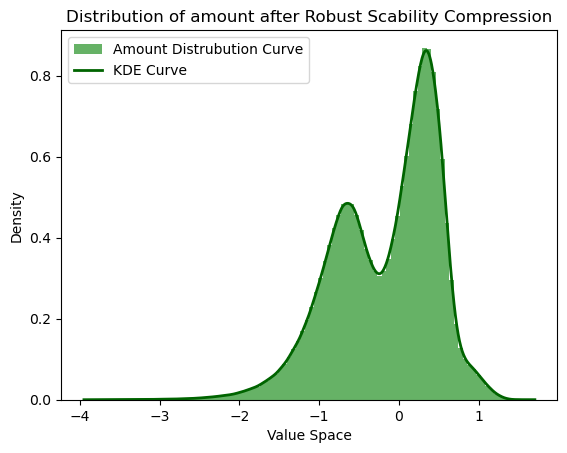

In [13]:
# 1. Generate the normalized histogram canvas for the transformed and compressed dataset column Amount
# Note: density=True is mandatory for the curve's area to align with the bars

plt.hist(complete_vector_compressed[:, 0], bins=100, density=True, alpha=0.6, color='g', label='Amount Distrubution Curve')

# 2. Compute the non-parametric density estimation
kde = gaussian_kde(complete_vector_compressed[:, 0])

# 3. Create a continuous, linearly spaced axis line across the data range
x_axis = np.linspace(complete_vector_compressed[:, 0].min(), complete_vector_compressed[:, 0].max(), 1000)

# 4. Project the curve over the histogram
plt.plot(x_axis, kde(x_axis), color='darkgreen', linewidth=2, label='KDE Curve')

plt.title('Distribution of amount after Robust Scability Compression')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

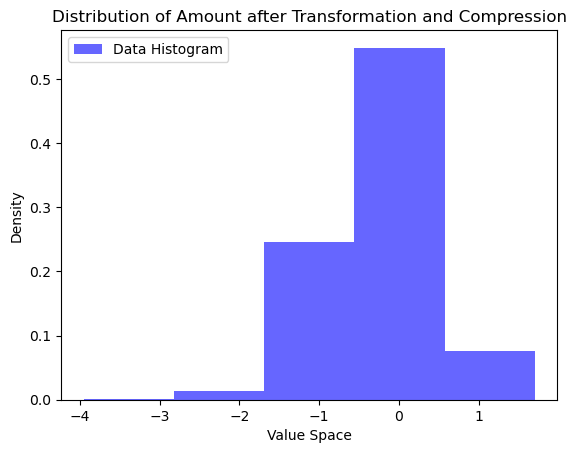

In [14]:
plt.hist(complete_vector_compressed[:, 0], bins=5, density=True, alpha=0.6, color='b', label='Data Histogram')

plt.title('Distribution of Amount after Transformation and Compression')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

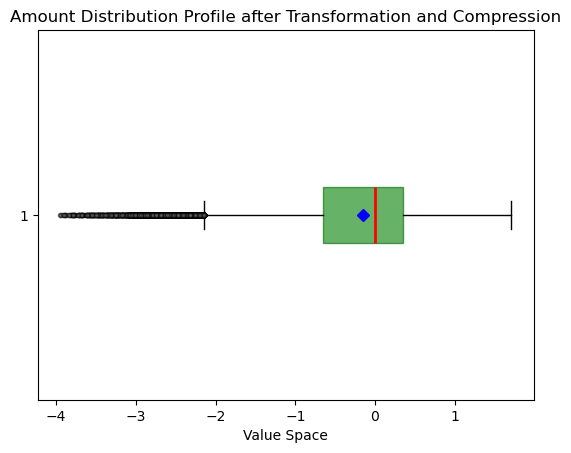

In [15]:
plt.boxplot(complete_vector_compressed[:, 0], 
            vert=False, 
            patch_artist=True,
            showmeans=True,  # <-- CRITICAL TRIGGER REQUIRED FOR meanprops
            boxprops=dict(facecolor='g', color='darkgreen', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='blue', markerfacecolor='blue', markersize=6),
            flierprops=dict(marker='o', markerfacecolor='dimgray', markersize=3, alpha=0.5))

plt.title('Amount Distribution Profile after Transformation and Compression')
plt.xlabel('Value Space')
plt.show()

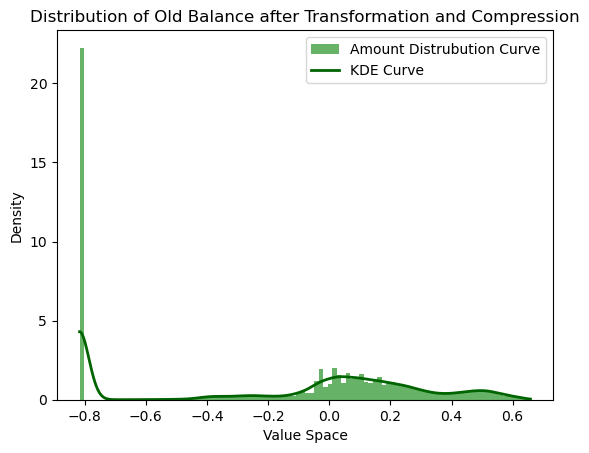

In [16]:
# 1. Generate the normalized histogram canvas for the transformed and compressed dataset column Old Balance
# Note: density=True is mandatory for the curve's area to align with the bars
data_slice2 = complete_vector_compressed[:, 1]
plt.hist(data_slice2, bins=100, density=True, alpha=0.6, color='g', label='Amount Distrubution Curve')

# 2. Compute the non-parametric density estimation
kde = gaussian_kde(data_slice2)

# 3. Create a continuous, linearly spaced axis line across the data range
x_axis = np.linspace(data_slice2.min(), data_slice2.max(), 1000)

# 4. Project the curve over the histogram
plt.plot(x_axis, kde(x_axis), color='darkgreen', linewidth=2, label='KDE Curve')

plt.title('Distribution of Old Balance after Transformation and Compression')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

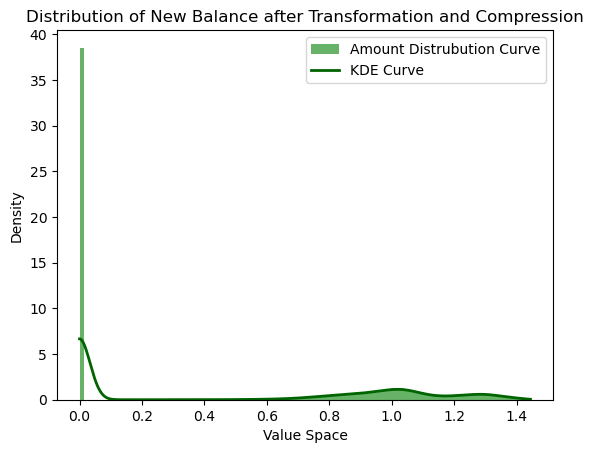

In [17]:
# 1. Generate the normalized histogram canvas for the transformed and compressed dataset column New Balance
# Note: density=True is mandatory for the curve's area to align with the bars
data_slice2 = complete_vector_compressed[:, 2]
plt.hist(data_slice2, bins=100, density=True, alpha=0.6, color='g', label='Amount Distrubution Curve')

# 2. Compute the non-parametric density estimation
kde = gaussian_kde(data_slice2)

# 3. Create a continuous, linearly spaced axis line across the data range
x_axis = np.linspace(data_slice2.min(), data_slice2.max(), 1000)

# 4. Project the curve over the histogram
plt.plot(x_axis, kde(x_axis), color='darkgreen', linewidth=2, label='KDE Curve')

plt.title('Distribution of New Balance after Transformation and Compression')
plt.xlabel('Value Space')
plt.ylabel('Density')
plt.legend()
plt.show()

In [18]:
print("\n=== Initializing Dimensional Split ===")


# 1. The Matrix Schism (80% Training / 20% Validation)
# We map the scaled 2D matrix (X) to the pure 1D target vector (Y)
X_train, X_test, y_train, y_test = train_test_split(
    complete_vector_compressed, 
    y_target, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_target # CRITICAL: Ensures the rare fraud cases are evenly distributed
)


=== Initializing Dimensional Split ===


In [19]:
print(f"Training Tensor Shape: {X_train.shape}")
print(f"Validation Tensor Shape: {X_test.shape}")

Training Tensor Shape: (799999, 3)
Validation Tensor Shape: (200000, 3)


In [20]:
# 1. Define the Objective Function
# 1. Switch to F2 (recall-weighted) — correct for fraud
f2_scorer = make_scorer(fbeta_score, beta=2)


# 2. Define the Search Vector
param_grid = {'scale_pos_weight': [1, 5, 10, 20, 50, 100]}

# 3. Instantiate the Engine
base_engine = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# 4. Instantiate the Grid Search
optimal_search = GridSearchCV(
    estimator=base_engine,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=3, 
    verbose=1 # CRITICAL: This will output the progress of the fitting loop
)

# 5. EXECUTE THE FIT (The State Transition)
print("Initiating cross-validation matrix mapping. Standby...")
optimal_search.fit(X_train, y_train) 
print("Matrix mapping complete.")

# 6. Extract the Mathematical Absolute
print("\n=== Optimization Complete ===")
# This will now succeed because the object state has transitioned
print(f"The Mathematically Optimal scale_pos_weight is: {optimal_search.best_params_['scale_pos_weight']}")

best_model = optimal_search.best_estimator_       

# 7. Geometrical Efficacy Report
y_predictions = best_model.predict(X_test)
print("\n=== Supervised Learning Output Metrics ===")
print(confusion_matrix(y_test, y_predictions))
print("\n")
print(classification_report(y_test, y_predictions))

Initiating cross-validation matrix mapping. Standby...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Matrix mapping complete.

=== Optimization Complete ===
The Mathematically Optimal scale_pos_weight is: 20

=== Supervised Learning Output Metrics ===
[[199717    176]
 [    29     78]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199893
           1       0.31      0.73      0.43       107

    accuracy                           1.00    200000
   macro avg       0.65      0.86      0.72    200000
weighted avg       1.00      1.00      1.00    200000



In [31]:
print("\n=== Initializing Dimensional Split:  Manual Scenario validation ===")
# 1. The Matrix Schism (80% Training / 20% Validation)
# We map the scaled 2D matrix (X) to the pure 1D target vector (Y)
X_train, X_test, y_train, y_test = train_test_split(
    complete_vector_compressed,
    y_target,
    test_size=0.20,
    random_state=42,
    stratify=y_target  # CRITICAL: Ensures the rare fraud cases are evenly distributed
)


print(f"Training Tensor Shape: {X_train.shape}")
print(f"Validation Tensor Shape: {X_test.shape}")

# configure to test outcomes.  I cannot run the optimization due to RAM is deleted and future state cannot be calculated.
# Use Jupyter Notebooks
# neutral, fraud is 100 times painful than false alarms, 1-5 is a low penalty.
scale_pos = 30

# 2. Engine Parameterization
# XGBoost is highly optimized for imbalanced, spiked, tabular datasets
xgb_engine = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',       # Hardware acceleration for large continuous matrices
    max_depth=6,              # Limits the geometric depth to prevent overfitting
    learning_rate=0.1,        # The step size for gradient descent
    # Mathematical penalty multiplier for missing a fraud case
    scale_pos_weight=scale_pos,
    random_state=42
)

# 3. Model Training (The Algorithmic Mapping)
print("\n=== Executing Gradient Boosting Optimization... ===")
xgb_engine.fit(X_train, y_train)

# 4. Target Prediction Space
print("=== Generating Vector Predictions ===")
y_predictions = xgb_engine.predict(X_test)

# 5. Geometrical Efficacy Report
print("\n=== Supervised Learning Output Metrics ===")
print(confusion_matrix(y_test, y_predictions))
print("\n")
print(classification_report(y_test, y_predictions))



=== Initializing Dimensional Split:  Manual Scenario validation ===
Training Tensor Shape: (799999, 3)
Validation Tensor Shape: (200000, 3)

=== Executing Gradient Boosting Optimization... ===
=== Generating Vector Predictions ===

=== Supervised Learning Output Metrics ===
[[199665    228]
 [    23     84]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199893
           1       0.27      0.79      0.40       107

    accuracy                           1.00    200000
   macro avg       0.63      0.89      0.70    200000
weighted avg       1.00      1.00      1.00    200000



In [2]:
#Effect of changes in scale-pos-weight over the theoretical data management cost structure. 
#                         Optimistic scenario    Optimistic scenario    Optimistic scenario 
#                            (scale_pos 5)            (scale_pos 15)       (scale_pos 30)  
#False fraud positives            23                        118                  228
#True fraud positives             38                         62                   84
#Missed fraud cases               69                         45                   23

#*forecasted over 1 million records of synthetic data.  Not to use as reference.